My project focuses on premier league football teams and players. More specifically, our insights will involve a specific game that fans of these teams like to play called Fantasy Football. As part of this game, players will log onto an app, create a league with friends and pick out a team of the best players their budget allows them to get. Once these are selected, the picks are locked until the matchweek has concluded. Then, based on footballer performances, the players will win / lose points and thus the leaderboard is born. Every player has a different cost based on position, form and team. For example, sometimes a worse player will cost slightly more than a better player because the latter is on a worse team etc. This project will look at a analysing what exactly influences these prices and if they can be predicted to earn the most amount of points.

We'll first begin by installing some new python packages (used for fuzzy merging), then we'll import all of our packages together.

In [2]:
#!pip install python-Levenshtein
#!pip install fuzzywuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 34.1 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import requests
import sqlite3
from sqlalchemy import create_engine
from fuzzywuzzy import process

Next we write a piece of code that allows us to bring files into the google drive environment, making it easier to use them.

Here, we have two files to import, our main data source, a csv file named players.csv and an excel file named PL_Table.xlsx

In [5]:
from google.colab import files
uploaded = files.upload()

Saving players.csv to players.csv


In [14]:
football = pd.read_csv('players.csv', index_col='id')   #Creating our main dataframe

Our next stage of preparation will be to make use of our Excel / API sources. For the purposes of this project, we have chosen an API which gives us the schedules of all teams in the Premier League, past and present fixtures, and an excel sheet containing the standings.

We will use these together in order to determine which teams have the toughest matchups in the next matchday week.

In [12]:
standings = pd.read_excel('PL_Table.xlsx', sheet_name='League Table', usecols=[0,1], nrows = 20)
standings

,Rank,Team
0,1,Liverpool
1,2,Man City
2,3,Chelsea
3,4,Arsenal
4,5,Nott'm Forest
5,6,Brighton
6,7,Fulham
7,8,Newcastle
8,9,Aston Villa
9,10,Spurs


In [15]:
ranked_teams = football.merge(standings, how='left', left_on='team', right_on='Team')   #First we merge the two tables together to give us the rank / standing in the league table

#Next we'll define a function that assigns a rating based on a team's position in the table
def assign_strength_rating(Rank):
    if 1 <= Rank <= 3:
        return 'Extremely Strong'
    elif 4 <= Rank <= 8:
        return 'Strong'
    elif 9 <= Rank <= 17:
        return 'Mid'
    elif 18 <= Rank <= 20:
        return 'Weak'
    else:
        return 'Unknown'
ranked_teams['strength rating'] = ranked_teams['Rank'].apply(assign_strength_rating)    #function gets called when creating the new field
ranked_teams.head()

,name,now_cost,position,team,creativity,expected_assists,selected_rank_type,goals_conceded,ict_index_rank_type,penalties_order,...,assists,expected_goal_involvements_per_90,influence_rank_type,corners_and_indirect_freekicks_order,starts_per_90,influence_rank,event_points,Rank,Team,strength rating
0,Fábio Ferreira Vieira,54,MID,Arsenal,0.0,0.00,278,0,310,NaN,...,0,0.00,310,NaN,0.00,683,0,4,Arsenal,Strong
1,Gabriel Fernando de Jesus,68,FWD,Arsenal,63.6,0.12,36,2,32,NaN,...,0,0.39,37,NaN,0.79,373,0,4,Arsenal,Strong
2,Gabriel dos Santos Magalhães,62,DEF,Arsenal,68.2,0.50,5,13,12,NaN,...,1,0.19,13,NaN,1.08,42,0,4,Arsenal,Strong
3,Kai Havertz,79,FWD,Arsenal,145.2,1.15,9,14,6,3.0,...,1,0.51,10,NaN,1.00,62,0,4,Arsenal,Strong
4,Karl Hein,40,GKP,Arsenal,0.0,0.00,68,0,58,NaN,...,0,0.00,58,NaN,0.00,511,0,4,Arsenal,Strong


In [7]:
#Although free, this API only allows for a certain amount of calls a day so keeping this line of code on a separate line means you won't need to run this but once
url = 'https://api.football-data.org/v4/competitions/PL/matches'
headers = {'X-Auth-Token':'dedd5ce0b1154aadbf7b31b6aea11c60'}   #contains the key received from the providers
response = requests.get(url,headers=headers)
data = response.json()                                          #converting data to JSON format

In [11]:
# Create a list to store matchday data
matchday_data = []
# Iterate through matches and extract relevant information to put into our dataframe
for match in data['matches']:
    matchday_data.append({
        'Matchday': match['matchday'],
        'Home Team': match['homeTeam']['name'],
        'Away Team': match['awayTeam']['name'],
        'Home Score': match['score']['fullTime']['home'],
        'Away Score': match['score']['fullTime']['away'],
        'Status': match['status'],
        'Date': match['utcDate']
    })
# Create the DataFrame
matchday_df = pd.DataFrame(matchday_data)

matchday_df.groupby('Status')['Matchday'].count().head()
matchday_df[matchday_df['Matchday'] == 16]
matchday_16 = matchday_df[matchday_df['Matchday'] == 16]    #For the purposes of this exercise, we only need to look at matchday 16 as this is who the teams are playing next
matchday_16                                                 #As part of future projects, one could look to recreating this for all matchday weeks

,Matchday,Home Team,Away Team,Home Score,Away Score,Status,Date
150,16,Arsenal FC,Everton FC,NaN,NaN,TIMED,2024-12-14T15:00:00Z
151,16,Liverpool FC,Fulham FC,NaN,NaN,TIMED,2024-12-14T15:00:00Z
152,16,Newcastle United FC,Leicester City FC,NaN,NaN,TIMED,2024-12-14T15:00:00Z
153,16,Wolverhampton Wanderers FC,Ipswich Town FC,NaN,NaN,TIMED,2024-12-14T15:00:00Z
154,16,Nottingham Forest FC,Aston Villa FC,NaN,NaN,TIMED,2024-12-14T17:30:00Z
155,16,Brighton & Hove Albion FC,Crystal Palace FC,NaN,NaN,TIMED,2024-12-15T14:00:00Z
156,16,Manchester City FC,Manchester United FC,NaN,NaN,TIMED,2024-12-15T16:30:00Z
157,16,Chelsea FC,Brentford FC,NaN,NaN,TIMED,2024-12-15T19:00:00Z
158,16,Southampton FC,Tottenham Hotspur FC,NaN,NaN,TIMED,2024-12-15T19:00:00Z
159,16,AFC Bournemouth,West Ham United FC,NaN,NaN,TIMED,2024-12-16T20:00:00Z


Next, we must split the original data source into home team table and away team table. Once that is done, we can join the table above to each of them, then join them on themselves to get the opponent strength rating and finally, concatenate the tables together.

One thing to note here is that the team names in the API data source and that in the normal data source are different. In hindsight, the easiest thing to do to overcome this would've been to just rename the teams. In the interest of saving time however (which this method didn't), I found a method of merging using the fuzzywuzzy package which matches fields approximately.

In [16]:
#Used a SQL Engine to demonstrate its capabilities, a lot easier than regular pandas filter application
ranked_teams = ranked_teams.rename(columns={'Team': 'TeamName'})  #Needed to be renamed as it caused an error
engine = create_engine('sqlite://', echo=False)
ranked_teams.to_sql('football_table', con=engine, if_exists='replace', index=False)
queryhome = "select * from football_table where TeamName in ('Man City','Arsenal','Liverpool','Chelsea','Newcastle','Wolves','Nott''m Forest','Brighton','Southampton','Bournemouth')"
queryaway = "select * from football_table where TeamName in ('Everton','Fulham','Leicester','Ipswich','Spurs','Man Utd','Aston Villa','Crystal Palace','Brentford','West Ham')"
resulthome = pd.read_sql_query(queryhome, engine)
resultaway = pd.read_sql_query(queryaway, engine)
print(resultaway.shape)    #I do this at most steps, I've just deleted most of them, it's very good especially when creating new dataframes by merging etc. to check that the shape is as expected

(334, 80)


In [20]:
#it was necessary to split these up as the fuzzywuzzy application would try to connect everything from Home & Away to each team in the main dataset. This way,
#we can use the appropriate Home team merging with the home team dataframe and the same for away
#Home
choices = matchday_16['Home Team'].values.tolist()    #Creating a list containing all of the team names that are playing at home this matchday week

resulthome['close_team'] = resulthome['TeamName'].apply(lambda x: process.extractOne(x, choices)[0])    #Applying a quick function that extracts the approximate match of each team in the dataset

final_table_home = resulthome.merge(matchday_16[['Home Team', 'Away Team']], left_on='close_team', right_on='Home Team', how='left')    #Merging to obtain their opponents

final_table_home['venue']='Home'
final_table_home.rename(columns={'Home Team': 'Team', 'Away Team':'Opponent'}, inplace=True)

#Away
choices = matchday_16['Away Team'].values.tolist()

resultaway['close_team'] = resultaway['TeamName'].apply(lambda x: process.extractOne(x, choices)[0])

final_table_away = resultaway.merge(matchday_16[['Away Team','Home Team']], left_on='close_team', right_on='Away Team', how='left')

final_table_away['venue']='Away'
final_table_away.rename(columns={'Away Team': 'Team', 'Home Team':'Opponent'}, inplace=True)

#Some cleaning
final_table_home1 = final_table_home.merge(final_table_away[['Team','strength rating']], left_on='Opponent', right_on='Team', how='left',suffixes=('', '_opponent')).drop_duplicates()
final_table_away1 = final_table_away.merge(final_table_home[['Team','strength rating']], left_on='Opponent', right_on='Team', how='left',suffixes=('', '_opponent')).drop_duplicates()
final_table_home2 = final_table_home1.drop(columns=['TeamName','close_team','Team_opponent']).rename(columns={'strength rating_opponent':'opponent strength rating'})
final_table_away2 = final_table_away1.drop(columns=['TeamName','close_team','Team_opponent']).rename(columns={'strength rating_opponent':'opponent strength rating'})
final_table = pd.concat([final_table_home2, final_table_away2], ignore_index=True)

final_table.shape   #once again checking the shape to make sure it looks ok
#it's worth nothing that there are extra fields that never get used, it would take too long to remove them all and I'm sick

(693, 83)

The data is now fully prepared, it is time to perform some analysis and obtain some graphs, beginning with some simpler ones and then getting to some more difficult ones.

            sum  count
team                  
Man City   1736     29
Arsenal    1663     29
Liverpool  1652     29
Chelsea    1594     29
Spurs      1572     29
Man Utd    1524     29


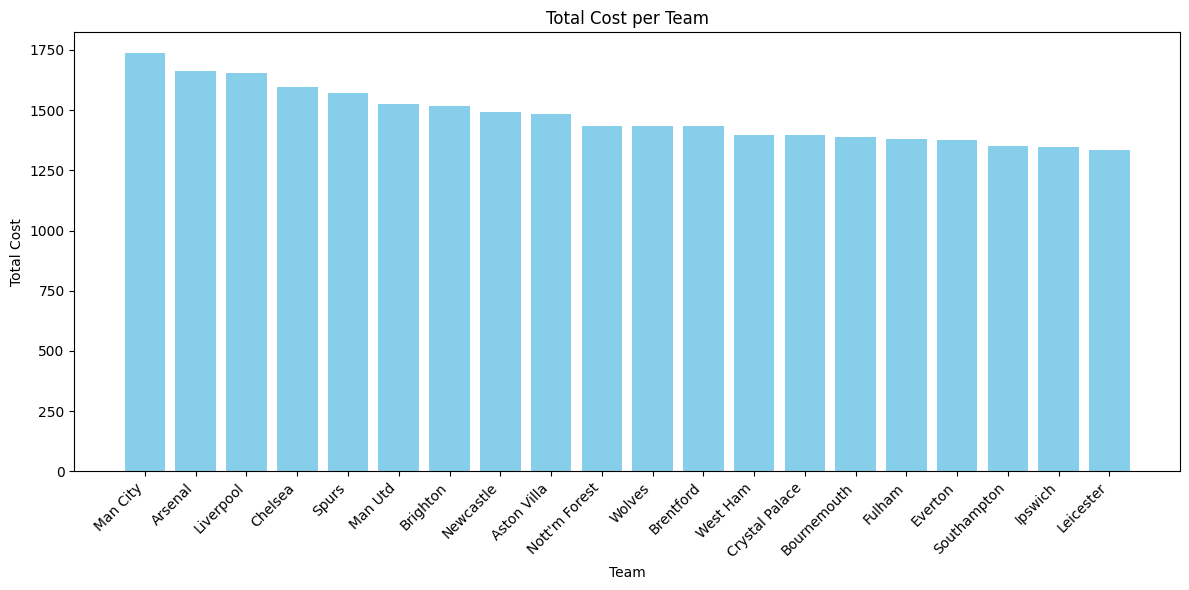

In [26]:
#Looking at the highest value teams according to the FPL app
team_value = (final_table.groupby('team')['now_cost']
                  .nlargest(29)  #Get the top 29 players from each team (since some teams had more and this would influence their total)
                  .groupby('team')
                  .agg(['sum', 'count'])
                  .sort_values(by=['sum'], ascending=False))

print(team_value.head(6))

#Extract team names and total costs to be used in bar chart below
teams = team_value.index
total_costs = team_value['sum']

plt.figure(figsize=(12, 6))  #I usually don't care about the size but it looks nicer because of the many teams
plt.bar(teams, total_costs, color='skyblue')
plt.xlabel("Team")
plt.ylabel("Total Cost")
plt.title("Total Cost per Team")
plt.xticks(rotation=45, ha='right')  #Rotates the labels to make them easier to read
plt.tight_layout()
plt.show()

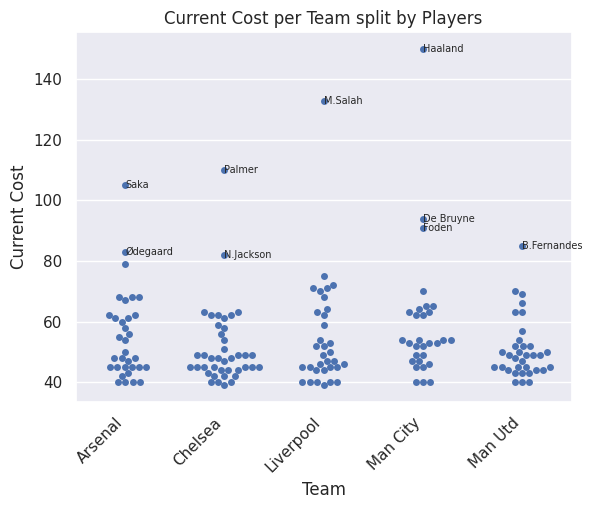

In [29]:
#A similar graph but only covering the top 5 most expensive teams and with more spread
sns.set()
top_six_teams = ['Man City', 'Liverpool', 'Arsenal', 'Man Utd', 'Chelsea', 'Tottenham']
highest_value_teams = final_table[final_table['team'].isin(top_six_teams)]
ax = sns.swarmplot(data=highest_value_teams, x='team', y='now_cost')

#Create a DataFrame for players with cost over 80
players_over_80 = highest_value_teams[highest_value_teams['now_cost'] > 80]

#Iterate through players_over_80 and add labels
for index, row in players_over_80.iterrows():
    ax.text(
        x=row['team'],
        y=row['now_cost'],
        s=row['web_name'],  # Use 'web_name' column for the label
        ha='left',
        va='center',size = 7
    )
plt.xlabel("Team")
plt.ylabel("Current Cost")
plt.title("Current Cost per Team split by Players")
plt.xticks(rotation=45, ha='right')
plt.show()

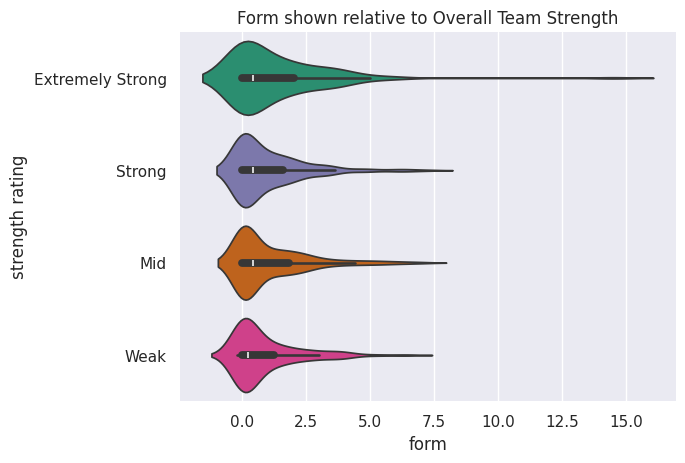

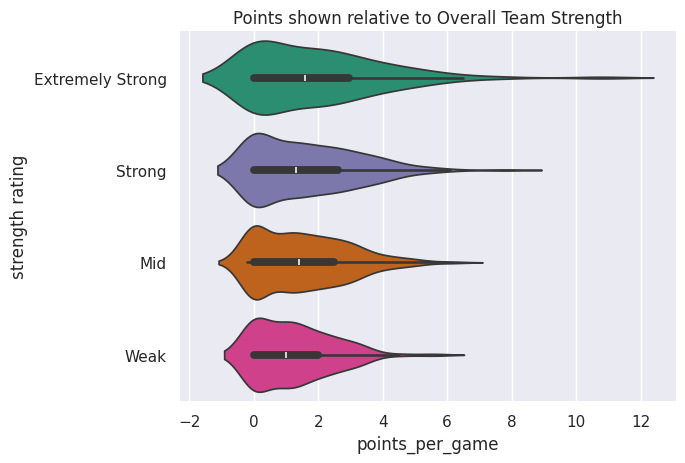

In [36]:
plt.figure()
strength_order = ['Extremely Strong', 'Strong', 'Mid', 'Weak']  #Need a custom ordering
sns.violinplot(final_table.sort_values(by='strength rating'), x='form', y='strength rating', inner='box', palette='Dark2', hue='strength rating', legend=False, order=strength_order)  #Apply custom order
sns.despine(top=True, right=True, bottom=True, left=True)
plt.title('Form shown relative to Overall Team Strength')
plt.figure()
strength_order = ['Extremely Strong', 'Strong', 'Mid', 'Weak']
sns.violinplot(final_table.sort_values(by='strength rating'), x='points_per_game', y='strength rating', inner='box', palette='Dark2', hue='strength rating', legend=False, order=strength_order)
sns.despine(top=True, right=True, bottom=True, left=True)
plt.title('Points shown relative to Overall Team Strength')
plt.show()    #graphs show a slight correlation between form and ppg, we can also see that the best teams have the most in form players
              #but that after that, there are a similar number of players from the rest of the teams that are in form and score well

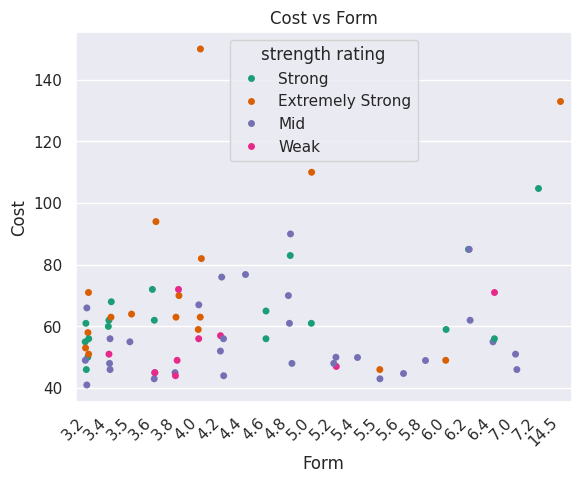

In [49]:
plt.figure()
final_table_form = final_table[final_table['form'] > 3]
sns.stripplot(final_table_form,
              x='form',
              y='now_cost',
              palette='Dark2',
              hue='strength rating')
plt.xlabel('Form')
plt.ylabel('Cost')
plt.title('Cost vs Form')
plt.xticks(rotation=45, ha='right')
plt.show()

Every person who starts playing Fantasy Premier League has a budget of 1000. To join the game select a fantasy football squad of 15 players, consisting of: 2 Goalkeepers. 5 Defenders. 5 Midfielders.

Most people will spend the majority of their money on the starting 11 and then buy the cheapest players (who are good) as the 4 subs. Since the cheapest players are worth roughly 45, four of these to make our subs bench would cost 180, leaving us with 820 to build the starting team with.

The average number of points scored per week (or a given matchday) is 24, sourced from Reddit.

In [50]:
#It's important to see which positions pay out the best
points_by_position = final_table.groupby('position')['points_per_game'].agg(['mean','std', 'min', 'max']).sort_values(by='mean',ascending=False)
points_by_position #From here it's clear that the forwards and the midfielders earn the most and therefore should have more spent on them

,mean,std,min,max
position,,,,
FWD,1.920000,1.955035,0.0,6.5
MID,1.626349,1.536966,0.0,10.8
GKP,1.473611,1.709624,0.0,5.8
DEF,1.404329,1.275378,-0.2,5.0


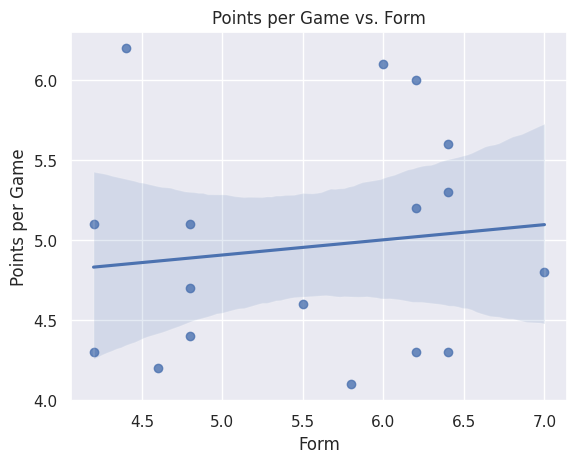

In [51]:
#I thought it would be interesting to try a scatter plot with a regression line to see if there'd be any correlation between form and points per game
#This very clearly shows that that is not the case, a player can have an amazing first week and a poor second second week, his mean ppg would still
#be high but his form would be low, form is the more important stat to look at when choosing players
formplot = final_table[(final_table['points_per_game'] > 4) & (final_table['form'] > 4) & (final_table['now_cost'] < 100)]
sns.regplot(x='form', y='points_per_game', data=formplot)
plt.title('Points per Game vs. Form')
plt.xlabel('Form')
plt.ylabel('Points per Game')
plt.show()

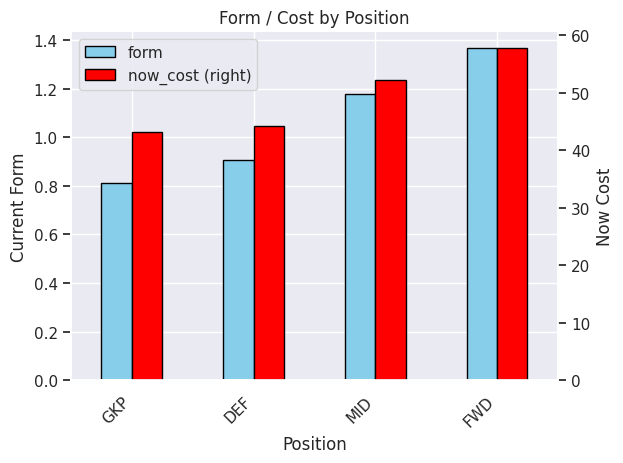

In [55]:
#Another great comparison to look at would be cost vs form, here we notice that a similarity relative to one another, for each
#position, except for striker, which currently sits slightly cheaper for the current form they're in
bar_plot = final_table.groupby('position').agg({'form': 'mean', 'now_cost': 'mean'}).sort_values(by='form')

#Create bar chart with secondary y-axis
ax = bar_plot.plot(kind='bar', secondary_y='now_cost', color=['skyblue', 'red'], edgecolor='black')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('Form / Cost by Position')
ax.set_xlabel('Position')
ax.set_ylabel('Current Form')
ax.right_ax.set_ylabel('Now Cost')
plt.tight_layout()
plt.show()

In [70]:
#Another way to determine who to pick is to look at who others are choosing
#In our dataset, we can see this and plot it (see data and graph below)
#We can see from the table that there are a number of cheaper options that many people are opting for with very high form, another important factor
#is looking at the strength rating, if you can, you'd prefer to have players from strong teams as they would be more likely to win but also those facing weaker teams
final_table[final_table['selected_by_percent'] > 20][['web_name', 'now_cost','form','selected_by_percent','Team','Opponent','strength rating','opponent strength rating']].sort_values(by='form', ascending=False).head(10)

,web_name,now_cost,form,selected_by_percent,Team,Opponent,strength rating,opponent strength rating
169,M.Salah,133,14.5,59.9,Liverpool FC,Fulham FC,Extremely Strong,Strong
13,Saka,105,7.2,42.4,Arsenal FC,Everton FC,Strong,Mid
328,Cunha,71,6.4,24.5,Wolverhampton Wanderers FC,Ipswich Town FC,Weak,Mid
80,João Pedro,59,6.0,21.7,Brighton & Hove Albion FC,Crystal Palace FC,Strong,Weak
14,Saliba,61,5.0,25.1,Arsenal FC,Everton FC,Strong,Mid
141,Palmer,110,5.0,59.4,Chelsea FC,Brentford FC,Extremely Strong,Mid
389,Watkins,90,4.8,24.0,Aston Villa FC,Nottingham Forest FC,Mid,Strong
410,Mbeumo,77,4.4,29.1,Brentford FC,Chelsea FC,Mid,Extremely Strong
643,Pedro Porro,56,4.2,29.6,Tottenham Hotspur FC,Southampton FC,Mid,Weak
139,N.Jackson,82,4.0,27.7,Chelsea FC,Brentford FC,Extremely Strong,Mid


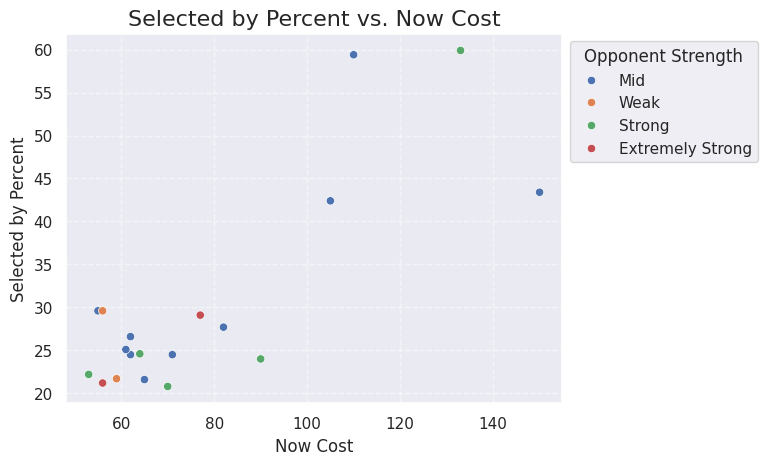

,name,now_cost,position,form,strength rating
169,Mohamed Salah,133,MID,14.5,Extremely Strong
13,Bukayo Saka,105,MID,7.2,Strong
417,Kevin Schade,51,MID,7.0,Mid
486,Ashley Young,46,DEF,7.0,Mid
328,Matheus Santos Carneiro Da Cunha,71,FWD,6.4,Weak
45,Justin Kluivert,55,MID,6.4,Mid
506,Alex Iwobi,56,MID,6.4,Strong
225,Alexander Isak,85,FWD,6.2,Strong
593,Bruno Borges Fernandes,85,MID,6.2,Mid
421,Yoane Wissa,62,FWD,6.2,Mid


In [74]:
plt.figure()
sns.scatterplot(x='now_cost', y='selected_by_percent', hue='opponent strength rating', data=final_table[final_table['selected_by_percent'] > 20], alpha=1)

plt.title('Selected by Percent vs. Now Cost', fontsize=16)
plt.xlabel('Now Cost', fontsize=12)
plt.ylabel('Selected by Percent', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Opponent Strength', loc='upper left', bbox_to_anchor=(1, 1))

#It's safe to assume from this graph that most players pick at least 2 very expensive players: Salah, Haaland, Palmer etc. then fill
#the rest of the team with lower rated players, you're incentivised to do this as you must pick a captain and vice captain who earn extra points
plt.show()

final_table.sort_values(by='form', ascending=False)[['name','now_cost','position','form','strength rating']].head(10)

From the above, we can conclude that we must first pick two players to be our captain and vice, these will be taken from the expensive pile. We'll also most likely want these players to be forwards as they are the most expensive players on average, the are also usually the ones most likely to score.

In [77]:
#Same table as above but for each individual position
print(final_table[final_table['position']=='GKP'].sort_values(by='form', ascending=False)[['web_name','now_cost', 'points_per_game','position','form','strength rating']].head())
print(final_table[final_table['position']=='DEF'].sort_values(by='form', ascending=False)[['web_name','now_cost', 'points_per_game','position','form','strength rating']].head())
print(final_table[final_table['position']=='MID'].sort_values(by='form', ascending=False)[['web_name','now_cost', 'points_per_game','position','form','strength rating']].head())
print(final_table[final_table['position']=='FWD'].sort_values(by='form', ascending=False)[['web_name','now_cost', 'points_per_game','position','form','strength rating']].head())

      web_name  now_cost  points_per_game position  form   strength rating
483   Pickford        49              4.1      GKP   5.8               Mid
166   Kelleher        46              4.6      GKP   5.5  Extremely Strong
610      Onana        52              4.3      GKP   4.2               Mid
441  Henderson        44              3.5      GKP   3.8              Weak
402    Flekken        45              3.1      GKP   3.6               Mid
        web_name  now_cost  points_per_game position  form strength rating
486        Young        46              4.8      DEF   7.0             Mid
664  Wan-Bissaka        45              3.1      DEF   5.6             Mid
480    Mykolenko        43              3.2      DEF   5.5             Mid
450        Muñoz        47              3.3      DEF   5.2            Weak
484    Tarkowski        48              3.1      DEF   5.2             Mid
     web_name  now_cost  points_per_game position  form   strength rating
169   M.Salah       133   

Pickford        49      GKP

Kelleher        46      GKP

Young           46      DEF

Wan-Bissaka     45      DEF

Mykolenko       43      DEF

Muñoz           47      DEF

M.Salah        133      MID

Saka           105      MID

Schade          51      MID

Iwobi           56      MID

Kluivert        55      MID

Wissa           62      FWD

Isak            85      FWD

João Pedro      59      FWD

Watkins         90      FWD

Total Cost: 972

Simply by following this current graph, we obtain a team that is in form and comes in under budget.

This would be the team that you'd recommend to someone who would start playing FPL right now. Of course, there are a lot more factors we haven't accounted for, like how these players could have very low points per game in general because their form is usually poor but it just so happens to be good now. In that sense, it would be important to take points per game into account. In our case, the average points per game out team would receive (not counting the bench or captain/vice double scores and assuming a 4-3-3 formation (DEF-MID-FWD)) is: 57.9, which is over double the average that a person would receive.